<a href="https://colab.research.google.com/github/iqlore-collab/API-PROJECTS/blob/main/flights_aerodatabox_api_github_enhanced_EN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Flight Data Collection and Analysis with AeroDataBox API

This notebook collects and analyzes airport arrival data using the AeroDataBox API via RapidAPI.

It is GitHub- and Colab-ready:

- no API keys are stored in the notebook,
- no database credentials are included,
- API calls use retry logic,
- results are exported to CSV,
- a `metadata.json` file documents the run,
- basic traffic analysis and visualizations are included.

The notebook is designed as a clean data engineering / API portfolio project.


## 1. Project workflow

The notebook performs the following steps:

1. Configure cities, airports, date, and output folder.
2. Search airports near selected city coordinates.
3. Download arrival flights for selected airport ICAO codes.
4. Flatten nested JSON API responses.
5. Clean date/time columns.
6. Build airport, airline, origin, and hourly traffic summaries.
7. Visualize flight traffic.
8. Export CSV files and metadata.


## 2. Setup

In [1]:
import json
import time
from datetime import datetime, timedelta
from getpass import getpass
from pathlib import Path

import requests
import pandas as pd
import matplotlib.pyplot as plt


## 3. Configuration

Edit this section to change:

- selected cities,
- selected airports,
- target date,
- output folder,
- API request behavior.

The API key is entered securely with `getpass`.


In [2]:
RAPIDAPI_KEY = getpass("Paste your RapidAPI key: ")

API_HOST = "aerodatabox.p.rapidapi.com"
BASE_URL = "https://aerodatabox.p.rapidapi.com"

HEADERS = {
    "X-RapidAPI-Key": RAPIDAPI_KEY,
    "X-RapidAPI-Host": API_HOST,
}

# Example cities used for airport search.
CITIES = [
    {"city": "Berlin", "lat": 52.5200, "lon": 13.4050},
    {"city": "Paris", "lat": 48.8566, "lon": 2.3522},
    {"city": "London", "lat": 51.5074, "lon": -0.1278},
    {"city": "Cologne", "lat": 50.9375, "lon": 6.9603},
]

# Airports used for flight arrival collection.
SELECTED_AIRPORTS = [
    "EDDB",  # Berlin Brandenburg
    "EDDK",  # Cologne Bonn
    "EGLL",  # London Heathrow
    "LFPG",  # Paris Charles de Gaulle
]

TARGET_DATE = (datetime.utcnow() + timedelta(days=1)).date()

TIME_WINDOWS = [
    (f"{TARGET_DATE}T00:00", f"{TARGET_DATE}T11:59"),
    (f"{TARGET_DATE}T12:00", f"{TARGET_DATE}T23:59"),
]

OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

REQUEST_SLEEP_SECONDS = 0.8
MAX_RETRIES = 3
TIMEOUT_SECONDS = 30


Paste your RapidAPI key: ··········


/tmp/ipykernel_4614/58778285.py:27: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  TARGET_DATE = (datetime.utcnow() + timedelta(days=1)).date()


## 4. API request helper with retry logic

APIs can fail temporarily because of rate limits, network issues, or server errors.

The helper below retries failed requests before giving up.


In [3]:
def safe_get_json(
    url: str,
    headers: dict,
    params: dict | None = None,
    timeout: int = TIMEOUT_SECONDS,
    max_retries: int = MAX_RETRIES,
    sleep_seconds: float = REQUEST_SLEEP_SECONDS,
):
    for attempt in range(1, max_retries + 1):
        try:
            response = requests.get(url, headers=headers, params=params, timeout=timeout)
            response.raise_for_status()
            return response.json()

        except requests.exceptions.HTTPError as error:
            status_code = getattr(error.response, "status_code", None)
            print(f"HTTP error on attempt {attempt}/{max_retries}: {error}")

            if status_code in [429, 500, 502, 503, 504] and attempt < max_retries:
                time.sleep(sleep_seconds * attempt)
                continue

            try:
                print("Response preview:", response.text[:500])
            except Exception:
                pass
            return None

        except requests.exceptions.RequestException as error:
            print(f"Request error on attempt {attempt}/{max_retries}: {error}")

            if attempt < max_retries:
                time.sleep(sleep_seconds * attempt)
                continue

            return None

        except ValueError:
            print("Could not parse JSON response.")
            return None

    return None


## 5. Search airports near selected cities

In [4]:
def search_airports_near_location(
    lat: float,
    lon: float,
    radius_km: int = 100,
    limit: int = 10,
):
    url = f"{BASE_URL}/airports/search/location/{lat}/{lon}/km/{radius_km}/{limit}"
    return safe_get_json(url, headers=HEADERS)


def flatten_airports_response(response, source_city: str) -> list[dict]:
    if not response or "items" not in response:
        return []

    rows = []

    for item in response["items"]:
        location = item.get("location", {}) or {}

        rows.append({
            "source_city": source_city,
            "airport_name": item.get("name"),
            "icao": item.get("icao"),
            "iata": item.get("iata"),
            "short_name": item.get("shortName"),
            "municipality_name": item.get("municipalityName"),
            "country_code": item.get("countryCode"),
            "lat": location.get("lat"),
            "lon": location.get("lon"),
        })

    return rows


In [5]:
airport_rows = []

for city in CITIES:
    print(f"Searching airports near {city['city']}...")

    response = search_airports_near_location(
        lat=city["lat"],
        lon=city["lon"],
        radius_km=100,
        limit=10,
    )

    airport_rows.extend(
        flatten_airports_response(response, source_city=city["city"])
    )

    time.sleep(REQUEST_SLEEP_SECONDS)

df_airports = pd.DataFrame(airport_rows)

df_airports


Searching airports near Berlin...
Searching airports near Paris...
Searching airports near London...
Searching airports near Cologne...


,source_city,airport_name,icao,iata,short_name,municipality_name,country_code,lat,lon
0,Berlin,Berlin -Tegel,EDDT,TXL,-Tegel,Berlin,DE,52.559700,13.287699
1,Berlin,Berlin Brandenburg,EDDB,BER,Brandenburg,Berlin,DE,52.351390,13.493889
2,Berlin,Trebbin Schönhagen,EDAZ,QXH,Schönhagen,Trebbin,DE,52.203610,13.156389
3,Berlin,Lärz Rechlin-,EDAX,REB,Rechlin-,Lärz,DE,53.306390,12.752222
4,Paris,Paris -Le Bourget,LFPB,LBG,-Le Bourget,Paris,FR,48.969400,2.441390
5,Paris,Villacoublay/Vélizy Villacoublay-Vélizy (BA 10...,LFPV,VIY,Villacoublay-Vélizy (BA 107) Air Base,Villacoublay/Vélizy,FR,48.774400,2.201539
6,Paris,Paris Orly,LFPO,ORY,Orly,Paris,FR,48.725300,2.359440
7,Paris,Toussus-le-Noble,LFPN,TNF,Toussus-le-Noble,Toussus-le-Noble,FR,48.751900,2.106189
8,Paris,Paris Charles de Gaulle,LFPG,CDG,Charles de Gaulle,Paris,FR,49.012800,2.549999
9,Paris,Pontoise - Cormeilles-en-Vexin,LFPT,POX,- Cormeilles-en-Vexin,Pontoise,FR,49.096600,2.040829


## 6. Download arrival flights

In [6]:
def get_airport_arrivals(
    airport_icao: str,
    start_time: str,
    end_time: str,
):
    url = f"{BASE_URL}/flights/airports/icao/{airport_icao}/{start_time}/{end_time}"
    params = {
        "direction": "Arrival",
        "withCancelled": "false",
        "withCodeshared": "true",
        "withCargo": "false",
        "withPrivate": "false",
    }

    return safe_get_json(url, headers=HEADERS, params=params)


def flatten_arrivals_response(response, airport_icao: str) -> list[dict]:
    if not response:
        return []

    arrivals = response.get("arrivals", [])
    rows = []

    for flight in arrivals:
        airline = flight.get("airline", {}) or {}
        aircraft = flight.get("aircraft", {}) or {}
        departure = flight.get("departure", {}) or {}
        arrival = flight.get("arrival", {}) or {}

        dep_airport = departure.get("airport", {}) or {}
        arr_airport = arrival.get("airport", {}) or {}

        dep_scheduled = departure.get("scheduledTime", {}) or {}
        dep_revised = departure.get("revisedTime", {}) or {}
        arr_scheduled = arrival.get("scheduledTime", {}) or {}
        arr_revised = arrival.get("revisedTime", {}) or {}

        rows.append({
            "arrival_airport_icao": airport_icao,
            "flight_number": flight.get("number"),
            "status": flight.get("status"),
            "airline_name": airline.get("name"),
            "airline_iata": airline.get("iata"),
            "airline_icao": airline.get("icao"),
            "aircraft_model": aircraft.get("model"),
            "aircraft_reg": aircraft.get("reg"),
            "departure_airport_name": dep_airport.get("name"),
            "departure_airport_icao": dep_airport.get("icao"),
            "departure_airport_iata": dep_airport.get("iata"),
            "arrival_airport_name": arr_airport.get("name"),
            "arrival_airport_iata": arr_airport.get("iata"),
            "scheduled_departure_local": dep_scheduled.get("local"),
            "revised_departure_local": dep_revised.get("local"),
            "scheduled_arrival_local": arr_scheduled.get("local"),
            "revised_arrival_local": arr_revised.get("local"),
        })

    return rows


In [7]:
arrival_rows = []
api_call_log = []

for airport_icao in SELECTED_AIRPORTS:
    for start_time, end_time in TIME_WINDOWS:
        print(f"Fetching arrivals for {airport_icao}: {start_time} -> {end_time}")

        response = get_airport_arrivals(
            airport_icao=airport_icao,
            start_time=start_time,
            end_time=end_time,
        )

        rows = flatten_arrivals_response(response, airport_icao=airport_icao)
        arrival_rows.extend(rows)

        api_call_log.append({
            "airport_icao": airport_icao,
            "start_time": start_time,
            "end_time": end_time,
            "rows_returned": len(rows),
            "success": response is not None,
        })

        time.sleep(REQUEST_SLEEP_SECONDS)

df_arrivals = pd.DataFrame(arrival_rows)
df_api_log = pd.DataFrame(api_call_log)

print("Arrival rows:", len(df_arrivals))
display(df_api_log)
display(df_arrivals.head())


Fetching arrivals for EDDB: 2026-05-20T00:00 -> 2026-05-20T11:59
Fetching arrivals for EDDB: 2026-05-20T12:00 -> 2026-05-20T23:59
Fetching arrivals for EDDK: 2026-05-20T00:00 -> 2026-05-20T11:59
Fetching arrivals for EDDK: 2026-05-20T12:00 -> 2026-05-20T23:59
Fetching arrivals for EGLL: 2026-05-20T00:00 -> 2026-05-20T11:59
Fetching arrivals for EGLL: 2026-05-20T12:00 -> 2026-05-20T23:59
Fetching arrivals for LFPG: 2026-05-20T00:00 -> 2026-05-20T11:59
Fetching arrivals for LFPG: 2026-05-20T12:00 -> 2026-05-20T23:59
Arrival rows: 5549


,airport_icao,start_time,end_time,rows_returned,success
0,EDDB,2026-05-20T00:00,2026-05-20T11:59,139,True
1,EDDB,2026-05-20T12:00,2026-05-20T23:59,313,True
2,EDDK,2026-05-20T00:00,2026-05-20T11:59,34,True
3,EDDK,2026-05-20T12:00,2026-05-20T23:59,61,True
4,EGLL,2026-05-20T00:00,2026-05-20T11:59,1075,True
5,EGLL,2026-05-20T12:00,2026-05-20T23:59,1463,True
6,LFPG,2026-05-20T00:00,2026-05-20T11:59,1090,True
7,LFPG,2026-05-20T12:00,2026-05-20T23:59,1374,True


,arrival_airport_icao,flight_number,status,airline_name,airline_iata,airline_icao,aircraft_model,aircraft_reg,departure_airport_name,departure_airport_icao,departure_airport_iata,arrival_airport_name,arrival_airport_iata,scheduled_departure_local,revised_departure_local,scheduled_arrival_local,revised_arrival_local
0,EDDB,SR 127,Expected,SundAir,SR,SDR,Airbus A320,None,None,None,None,None,None,None,None,None,None
1,EDDB,HU 489,Expected,Hainan,HU,CHH,Boeing 787-9,None,None,None,None,None,None,None,None,None,None
2,EDDB,XQ 1768,Expected,Sun Express,XQ,SXS,Boeing 737 MAX 8,None,None,None,None,None,None,None,None,None,None
3,EDDB,W4 3109,Expected,Aero Services Executive,W4,WMT,Airbus A321-200,None,None,None,None,None,None,None,None,None,None
4,EDDB,UA 962,Expected,United,UA,UAL,Boeing 767-300 (winglets),None,None,None,None,None,None,None,None,None,None


## 7. Clean date/time columns

In [8]:
datetime_cols = [
    "scheduled_departure_local",
    "revised_departure_local",
    "scheduled_arrival_local",
    "revised_arrival_local",
]

for col in datetime_cols:
    if col in df_arrivals.columns:
        df_arrivals[col] = pd.to_datetime(df_arrivals[col], errors="coerce")

if "scheduled_arrival_local" in df_arrivals.columns:
    df_arrivals["arrival_date"] = df_arrivals["scheduled_arrival_local"].dt.date
    df_arrivals["arrival_hour"] = df_arrivals["scheduled_arrival_local"].dt.hour

df_arrivals.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5549 entries, 0 to 5548
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   arrival_airport_icao       5549 non-null   object        
 1   flight_number              5549 non-null   object        
 2   status                     5549 non-null   object        
 3   airline_name               5549 non-null   object        
 4   airline_iata               5436 non-null   object        
 5   airline_icao               5437 non-null   object        
 6   aircraft_model             5540 non-null   object        
 7   aircraft_reg               258 non-null    object        
 8   departure_airport_name     0 non-null      object        
 9   departure_airport_icao     0 non-null      object        
 10  departure_airport_iata     0 non-null      object        
 11  arrival_airport_name       0 non-null      object        
 12  arriva

## 8. Airport-level arrival summary

In [9]:
if not df_arrivals.empty:
    airport_summary = (
        df_arrivals
        .groupby("arrival_airport_icao", as_index=False)
        .agg(
            arrivals=("flight_number", "count"),
            unique_airlines=("airline_name", "nunique"),
            unique_origin_airports=("departure_airport_icao", "nunique"),
        )
        .sort_values("arrivals", ascending=False)
    )
else:
    airport_summary = pd.DataFrame(
        columns=["arrival_airport_icao", "arrivals", "unique_airlines", "unique_origin_airports"]
    )

airport_summary


,arrival_airport_icao,arrivals,unique_airlines,unique_origin_airports
2,EGLL,2538,92,0
3,LFPG,2464,103,0
0,EDDB,452,81,0
1,EDDK,95,17,0


## 9. Airline and origin airport analysis

In [10]:
if not df_arrivals.empty:
    top_airlines = (
        df_arrivals["airline_name"]
        .value_counts(dropna=False)
        .rename_axis("airline_name")
        .reset_index(name="arrivals")
        .head(15)
    )

    top_origins = (
        df_arrivals
        .groupby(["departure_airport_icao", "departure_airport_name"], dropna=False)
        .size()
        .reset_index(name="arrivals")
        .sort_values("arrivals", ascending=False)
        .head(15)
    )
else:
    top_airlines = pd.DataFrame(columns=["airline_name", "arrivals"])
    top_origins = pd.DataFrame(columns=["departure_airport_icao", "departure_airport_name", "arrivals"])

display(top_airlines)
display(top_origins)


,airline_name,arrivals
0,Air France,447
1,British,425
2,Delta Air Lines,309
3,American,295
4,Aeromexico,245
5,KLM,216
6,Qatar,175
7,Air Mauritius,158
8,Iberia,151
9,SAS,145


,departure_airport_icao,departure_airport_name,arrivals
0,NaN,NaN,5549


## 10. Arrivals by hour

In [11]:
if not df_arrivals.empty and "arrival_hour" in df_arrivals.columns:
    arrivals_by_hour = (
        df_arrivals
        .groupby(["arrival_airport_icao", "arrival_hour"], as_index=False)
        .size()
        .rename(columns={"size": "arrivals"})
    )
else:
    arrivals_by_hour = pd.DataFrame(columns=["arrival_airport_icao", "arrival_hour", "arrivals"])

arrivals_by_hour.head()


,arrival_airport_icao,arrival_hour,arrivals


## 11. Visualizations

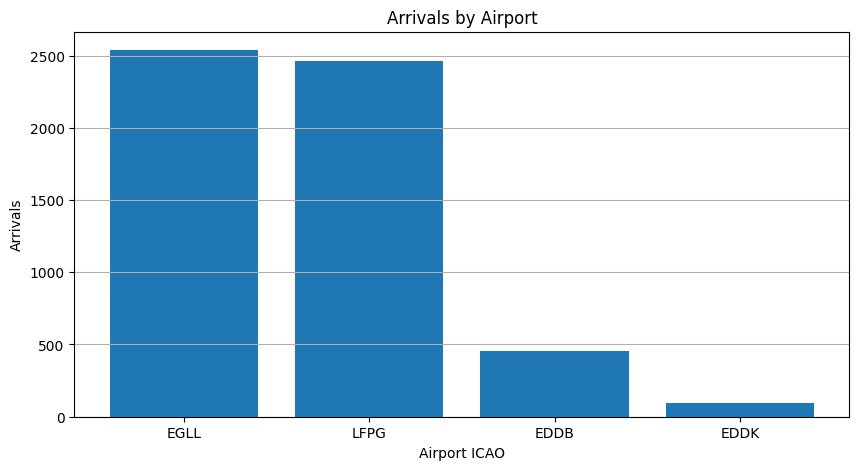

In [12]:
if not airport_summary.empty:
    plt.figure(figsize=(10, 5))
    plt.bar(airport_summary["arrival_airport_icao"], airport_summary["arrivals"])
    plt.title("Arrivals by Airport")
    plt.xlabel("Airport ICAO")
    plt.ylabel("Arrivals")
    plt.grid(axis="y")
    plt.show()
else:
    print("No airport summary data to plot.")


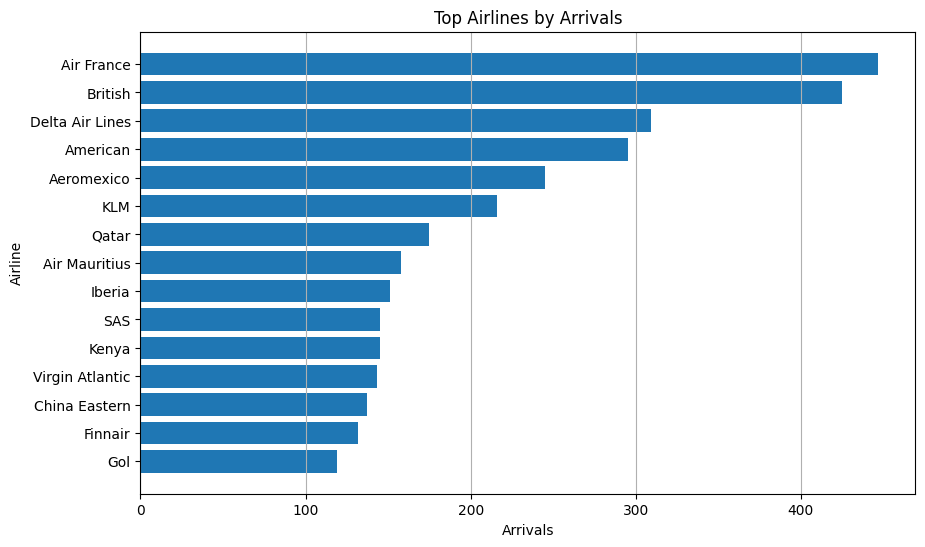

In [13]:
if not top_airlines.empty:
    plt.figure(figsize=(10, 6))
    plt.barh(top_airlines["airline_name"].astype(str), top_airlines["arrivals"])
    plt.title("Top Airlines by Arrivals")
    plt.xlabel("Arrivals")
    plt.ylabel("Airline")
    plt.gca().invert_yaxis()
    plt.grid(axis="x")
    plt.show()
else:
    print("No airline data to plot.")


In [14]:
if not arrivals_by_hour.empty:
    plt.figure(figsize=(12, 6))

    for airport in arrivals_by_hour["arrival_airport_icao"].unique():
        data = arrivals_by_hour[arrivals_by_hour["arrival_airport_icao"] == airport]
        plt.plot(data["arrival_hour"], data["arrivals"], marker="o", label=airport)

    plt.title("Arrivals by Hour")
    plt.xlabel("Hour")
    plt.ylabel("Arrivals")
    plt.xticks(range(0, 24))
    plt.legend()
    plt.grid(True)
    plt.show()
else:
    print("No hourly data to plot.")


No hourly data to plot.


## 12. Inspect arrivals for a selected airport

In [15]:
def show_airport_arrivals(df: pd.DataFrame, airport_icao: str, limit: int = 20) -> pd.DataFrame:
    if df.empty:
        return df

    cols = [
        "arrival_airport_icao",
        "flight_number",
        "status",
        "airline_name",
        "departure_airport_name",
        "departure_airport_icao",
        "scheduled_arrival_local",
        "revised_arrival_local",
    ]

    cols = [col for col in cols if col in df.columns]

    return (
        df[df["arrival_airport_icao"] == airport_icao]
        .sort_values("scheduled_arrival_local")
        [cols]
        .head(limit)
    )


show_airport_arrivals(df_arrivals, SELECTED_AIRPORTS[0])


,arrival_airport_icao,flight_number,status,airline_name,departure_airport_name,departure_airport_icao,scheduled_arrival_local,revised_arrival_local
0,EDDB,SR 127,Expected,SundAir,None,None,NaT,NaT
1,EDDB,HU 489,Expected,Hainan,None,None,NaT,NaT
2,EDDB,XQ 1768,Expected,Sun Express,None,None,NaT,NaT
3,EDDB,W4 3109,Expected,Aero Services Executive,None,None,NaT,NaT
4,EDDB,UA 962,Expected,United,None,None,NaT,NaT
5,EDDB,LH 170,Expected,Lufthansa,None,None,NaT,NaT
6,EDDB,FR 2669,Expected,Ryanair,None,None,NaT,NaT
7,EDDB,DL 7312,Expected,Delta Air Lines,None,None,NaT,NaT
8,EDDB,BT 211,Expected,airBaltic,None,None,NaT,NaT
9,EDDB,A3 3209,Expected,Aegean,None,None,NaT,NaT


## 13. Export results

In [16]:
airports_path = OUTPUT_DIR / "airports_near_cities.csv"
arrivals_path = OUTPUT_DIR / "flight_arrivals.csv"
summary_path = OUTPUT_DIR / "airport_arrival_summary.csv"
airlines_path = OUTPUT_DIR / "top_airlines.csv"
origins_path = OUTPUT_DIR / "top_origin_airports.csv"
hourly_path = OUTPUT_DIR / "arrivals_by_hour.csv"
api_log_path = OUTPUT_DIR / "api_call_log.csv"
metadata_path = OUTPUT_DIR / "metadata.json"

df_airports.to_csv(airports_path, index=False)
df_arrivals.to_csv(arrivals_path, index=False)
airport_summary.to_csv(summary_path, index=False)
top_airlines.to_csv(airlines_path, index=False)
top_origins.to_csv(origins_path, index=False)
arrivals_by_hour.to_csv(hourly_path, index=False)
df_api_log.to_csv(api_log_path, index=False)

metadata = {
    "run_timestamp_utc": datetime.utcnow().isoformat(),
    "target_date": str(TARGET_DATE),
    "selected_airports": SELECTED_AIRPORTS,
    "cities": CITIES,
    "time_windows": TIME_WINDOWS,
    "rows": {
        "airports": int(len(df_airports)),
        "arrivals": int(len(df_arrivals)),
        "api_calls": int(len(df_api_log)),
    },
    "output_files": [
        str(airports_path),
        str(arrivals_path),
        str(summary_path),
        str(airlines_path),
        str(origins_path),
        str(hourly_path),
        str(api_log_path),
    ],
}

with open(metadata_path, "w", encoding="utf-8") as file:
    json.dump(metadata, file, indent=2)

print("Saved files:")
for path in [
    airports_path,
    arrivals_path,
    summary_path,
    airlines_path,
    origins_path,
    hourly_path,
    api_log_path,
    metadata_path,
]:
    print(path)


Saved files:
outputs/airports_near_cities.csv
outputs/flight_arrivals.csv
outputs/airport_arrival_summary.csv
outputs/top_airlines.csv
outputs/top_origin_airports.csv
outputs/arrivals_by_hour.csv
outputs/api_call_log.csv
outputs/metadata.json


/tmp/ipykernel_4614/4127595530.py:19: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "run_timestamp_utc": datetime.utcnow().isoformat(),


## 14. Optional database loading

For a production-style workflow, the exported CSV files can be loaded into a database later.

This notebook intentionally does not include database credentials.

Recommended approach:

1. export CSV files,
2. store credentials in environment variables,
3. load data using a separate private script or notebook.


## 15. Limitations

- The notebook requires a RapidAPI key.
- Free API plans may have rate limits.
- Flight data is time-sensitive.
- Some airports may return no flights for the selected window.
- API response schemas can change.
- This is a data collection and analysis prototype, not a production ETL pipeline.


## 16. Final notes

This improved notebook is suitable for GitHub because it:

- does not expose secrets,
- avoids local database dependencies,
- uses retry logic,
- exports reproducible files,
- creates metadata for each run,
- includes basic analysis and visualizations.
